>>> Konfigurasi: TF Legacy & CPU Mode



c:\Users\Acer\Desktop\Semester 7\Alpro 2\UAS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>>> [1/5] Mencari File Dataset...
✅ DATASET: c:\Users\Acer\Desktop\Semester 7\Alpro 2\UAS\data\Twitter_Emotion_Dataset.csv
✅ KAMUS: c:\Users\Acer\Desktop\Semester 7\Alpro 2\UAS\data\kamus_singkatan.csv
>>> [2/5] Preprocessing...
>>> [3/5] Tokenizing...


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


>>> [4/5] Loading indolem/indobertweet-base-uncased & Training...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


c:\Users\Acer\Desktop\Semester 7\Alpro 2\UAS\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Acer\.cache\huggingface\hub\models--indolem--indobertweet-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We r

Epoch 1/3


220/220 [==============================] - 766s 3s/step - loss: 0.9641 - accuracy: 0.6321 - val_loss: 0.6624 - val_accuracy: 0.7673
Epoch 2/3
220/220 [==============================] - 793s 4s/step - loss: 0.4484 - accuracy: 0.8523 - val_loss: 0.6905 - val_accuracy: 0.7684
Epoch 3/3
220/220 [==============================] - 751s 3s/step - loss: 0.2136 - accuracy: 0.9341 - val_loss: 0.7618 - val_accuracy: 0.7684
>>> [5/5] Evaluasi...
56/56 [==============================] - 60s 1s/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       anger       0.90      0.72      0.80       220
        fear       0.84      0.77      0.80       130
       happy       0.76      0.81      0.78       204
        love       0.82      0.84      0.83       127
     sadness       0.62      0.73      0.67       200

    accuracy                           0.77       881
   macro avg       0.79      0.77      0.78       881
weighted avg       0.78      0.7

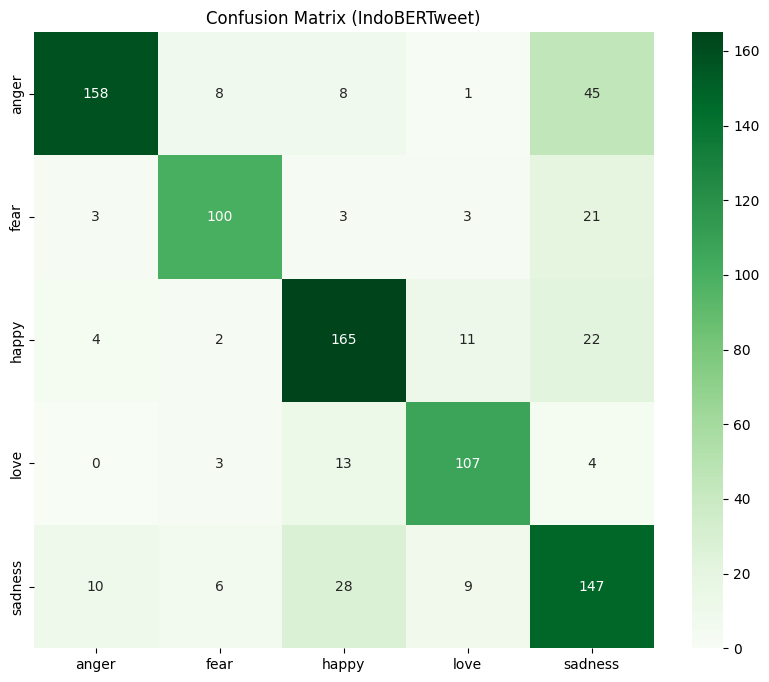

In [1]:
import os
import sys

# ==========================================
# 0. CONFIG WAJIB (KERAS 3 FIX + CONVERTER)
# ==========================================
# Force TF Legacy Mode (Keras 2) agar kompatibel
os.environ['TF_USE_LEGACY_KERAS'] = '1'
# Force CPU (Safe Mode)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 

print(">>> Konfigurasi: TF Legacy & CPU Mode")

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Cek Library Wajib
try:
    import tensorflow as tf
    import tf_keras
    import torch # WAJIB ADA untuk konversi weights
    from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
    from tensorflow.keras.optimizers import Adam
except ImportError as e:
    sys.exit(f"❌ Error Library: {e}\n👉 Solusi: pip install tf-keras torch transformers")

# ==========================================
# 1. SMART PATH FINDER
# ==========================================
print(">>> [1/5] Mencari File Dataset...")

target_file = 'Twitter_Emotion_Dataset.csv'
kamus_file = 'kamus_singkatan.csv'
found_csv = None
found_kamus = None

# Logic pencarian file
search_dirs = ['.', 'data', '..', '../data', '../..', 
               r'C:\Users\Acer\Desktop\Semester 7\Alpro 2\UAS'] 

for folder in search_dirs:
    if not os.path.exists(folder): continue
    p_csv = os.path.join(folder, target_file)
    if os.path.exists(p_csv): found_csv = os.path.abspath(p_csv)
    p_kamus = os.path.join(folder, kamus_file)
    if os.path.exists(p_kamus): found_kamus = os.path.abspath(p_kamus)
    if found_csv and found_kamus: break

if not found_csv:
    for root, dirs, files in os.walk(os.getcwd()):
        if target_file in files: found_csv = os.path.join(root, target_file)
        if kamus_file in files: found_kamus = os.path.join(root, kamus_file)
        if found_csv and found_kamus: break

if found_csv:
    print(f"✅ DATASET: {found_csv}")
    df = pd.read_csv(found_csv)
    
    if found_kamus:
        print(f"✅ KAMUS: {found_kamus}")
        df_kamus = pd.read_csv(found_kamus, sep=';', header=None, names=['slang', 'formal'])
        slang_dict = dict(zip(df_kamus['slang'], df_kamus['formal']))
    else:
        slang_dict = {}
else:
    sys.exit("❌ [FATAL] File Dataset tidak ditemukan.")

# ==========================================
# 2. PREPROCESSING (INDOBERTTWEET)
# ==========================================
print(">>> [2/5] Preprocessing...")

emoticon_patterns = {
    re.compile(r'(:\)|:-\)|\(:)'): ' emot_senyum ',
    re.compile(r'(:d|:D|😂|🤣)'): ' emot_tertawa ',
    re.compile(r'(:\(|:-\()'): ' emot_sedih ',
    re.compile(r'(:\'|T_T|😭|😢)'): ' emot_menangis ',
    re.compile(r'(-_-)'): ' emot_datar ',
    re.compile(r'(<3|❤|💕)'): ' emot_cinta ',
    re.compile(r'(😡|😠)'): ' emot_marah '
}

def clean_text_bertweet(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    for pattern, replacement in emoticon_patterns.items():
        text = pattern.sub(replacement, text)
    text = re.sub(r'@[\w]+', '', text) # Hapus mention
    text = re.sub(r'https?://\S+', '', text) # Hapus link
    words = text.split()
    if slang_dict:
        words = [slang_dict.get(w, w) for w in words]
    text = ' '.join(words)
    text = re.sub(r'[^a-z0-9!?.,\s]', '', text)
    return " ".join(text.split())

df['tweet_clean'] = df['tweet'].apply(clean_text_bertweet)

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
LABELS = le.classes_
NUM_LABELS = len(LABELS)

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['tweet_clean'].values, 
    df['label_enc'].values, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label_enc'].values
)

# ==========================================
# 3. TOKENIZATION
# ==========================================
print(">>> [3/5] Tokenizing...")

MODEL_NAME = "indolem/indobertweet-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 70 
BATCH_SIZE = 16

def tokenize_data(texts):
    return tokenizer(
        text=texts.tolist(),
        add_special_tokens=True,
        max_length=MAX_LEN,
        truncation=True,
        padding=True, 
        return_tensors='tf',
        return_token_type_ids=False,
        return_attention_mask=True,
        verbose=True
    )

X_train_token = tokenize_data(X_train_txt)
X_test_token = tokenize_data(X_test_txt)

def make_tf_dataset(tokens, labels):
    return tf.data.Dataset.from_tensor_slices((
        dict(tokens),
        labels
    )).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_tf_dataset(X_train_token, y_train)
test_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_test_token),
    y_test
)).batch(BATCH_SIZE)

# ==========================================
# 4. TRAINING (FIXED)
# ==========================================
print(f">>> [4/5] Loading {MODEL_NAME} & Training...")

# TAMBAHAN: from_pt=True agar bisa load PyTorch weights
try:
    model = TFAutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, 
        num_labels=NUM_LABELS,
        from_pt=True 
    )
except Exception as e:
    sys.exit(f"❌ Gagal load model: {e}\nPastikan torch sudah terinstall!")

optimizer = Adam(learning_rate=2e-5)
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
              metrics=['accuracy'])

# Train 3 epoch
history = model.fit(train_ds, validation_data=test_ds, epochs=3)

# ==========================================
# 5. EVALUASI
# ==========================================
print(">>> [5/5] Evaluasi...")

y_pred_logits = model.predict(test_ds).logits
y_pred_classes = np.argmax(y_pred_logits, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_classes, target_names=LABELS))

plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=LABELS, yticklabels=LABELS)
plt.title('Confusion Matrix (IndoBERTweet)')
plt.show()

In [2]:
import os

# Nama folder penyimpanan (Penting: Folder ini yang akan dibaca app.py)
save_directory = "my_bert_model"

# Buat folder
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

print(f">>> Menyimpan model ke folder '{save_directory}'...")

# 1. Simpan Weights & Config
model.save_pretrained(save_directory)

# 2. Simpan Tokenizer (Agar app.py tahu cara baca teks)
tokenizer.save_pretrained(save_directory)

print("✅ SUKSES! Model aman disimpan.")
print(f"Sekarang Anda bisa menjalankan 'app.py' dan model ini akan otomatis dimuat.")

>>> Menyimpan model ke folder 'my_bert_model'...
✅ SUKSES! Model aman disimpan.
Sekarang Anda bisa menjalankan 'app.py' dan model ini akan otomatis dimuat.
